In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "breast_cancer_dataset" / "data.csv"
df = pd.read_csv(train_path)

In [7]:
X = df.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore")
y = (df["diagnosis"] == "M").astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000)),
])
model.fit(X_train, y_train)
prob = model.predict_proba(X_valid)[:, 1]


threshold=0.50
[[89  1]
 [ 4 49]]
              precision    recall  f1-score   support

           0      0.957     0.989     0.973        90
           1      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143



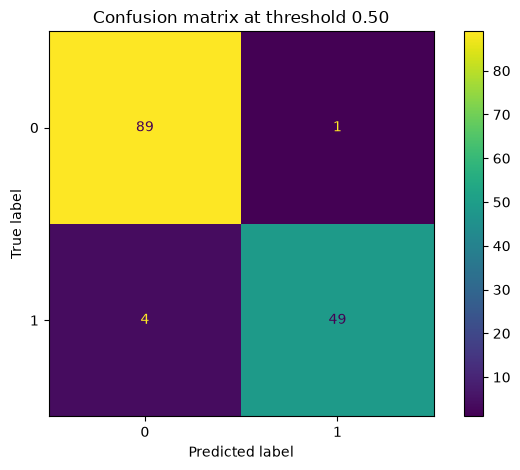


threshold=0.30
[[89  1]
 [ 2 51]]
              precision    recall  f1-score   support

           0      0.978     0.989     0.983        90
           1      0.981     0.962     0.971        53

    accuracy                          0.979       143
   macro avg      0.979     0.976     0.977       143
weighted avg      0.979     0.979     0.979       143



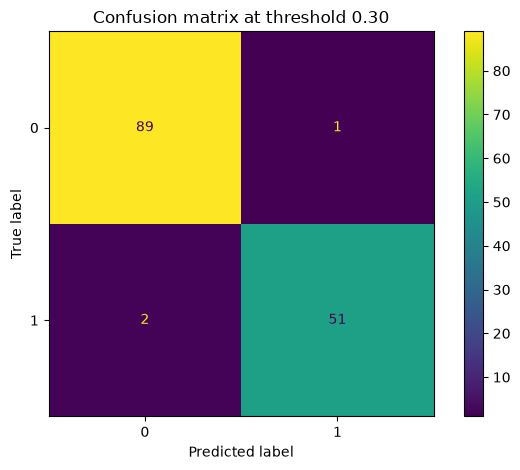

ROC AUC: 0.996
PR AUC: 0.994


In [8]:
# Explore threshold policies on development validation data, not a final test set.
for threshold in [0.50, 0.30]:
    pred = (prob >= threshold).astype(int)
    print(f"\nthreshold={threshold:.2f}")
    print(confusion_matrix(y_valid, pred))
    print(classification_report(y_valid, pred, digits=3))
    ConfusionMatrixDisplay.from_predictions(y_valid, pred)
    plt.title(f"Confusion matrix at threshold {threshold:.2f}")
    plt.tight_layout()
    plt.show()

print("ROC AUC:", round(roc_auc_score(y_valid, prob), 3))
print("PR AUC:", round(average_precision_score(y_valid, prob), 3))

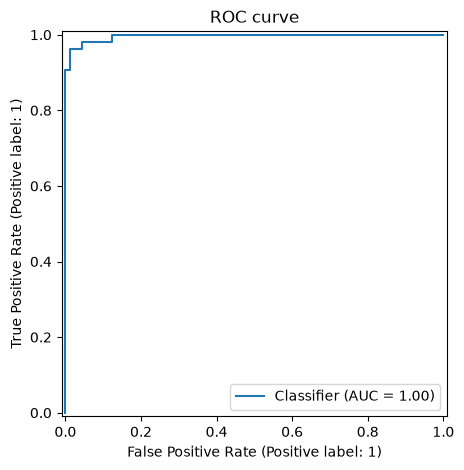

In [9]:
RocCurveDisplay.from_predictions(y_valid, prob)
plt.title("ROC curve")
plt.tight_layout()
plt.show()

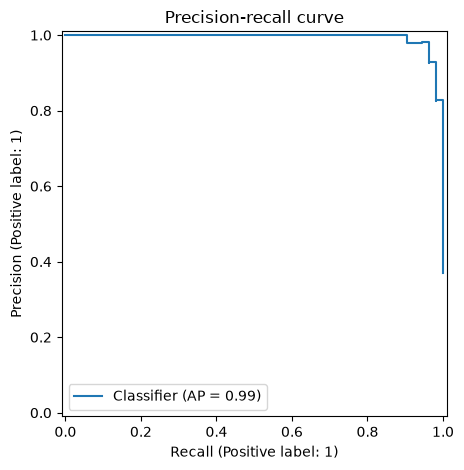

In [10]:
PrecisionRecallDisplay.from_predictions(y_valid, prob)
plt.title("Precision-recall curve")
plt.tight_layout()
plt.show()